# How Long Is a Storm? \U0001F32A
### Markets get wild and stay wild. For how long, exactly?

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Everyone knows volatility clusters. Ask a room of quants how long the clustering lasts and you
will get answers between a week and half a year — all of them computed correctly, from the same
data, by people who know what they are doing. This study finds out why.

> \U0001F4D3 **This is the plain-language layer.** The five estimators, the two-component fit and
> the planted-truth controls are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does volatility cluster? | Overwhelmingly. |
| What is the half-life? | Anywhere from a week to three months. |
| Which number is right? | All of them. Volatility has two timescales, not one. |
| Can you use it? | Yes — and the slow decay is what makes it usable. |

## 1 · Storms are visible to the naked eye

In [2]:
from storm import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
r = assets[data.EQUITY]
tbl = st.halflife_table(r, 21)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions")
print(tbl.round(2).to_string())

as-of 2026-06-30 | SPY: 7,764 sessions
         halflife                                  note
method                                                 
ar1       70.6900      phi = 0.9902 on 21d realised vol
acf       40.8700             |returns|, acf(1) = 0.271
garch     40.3300                   alpha+beta = 0.9830
ewma      11.2000   lambda = 0.94, assumed not measured
impulse   51.0000  388 shocks above the 95th percentile


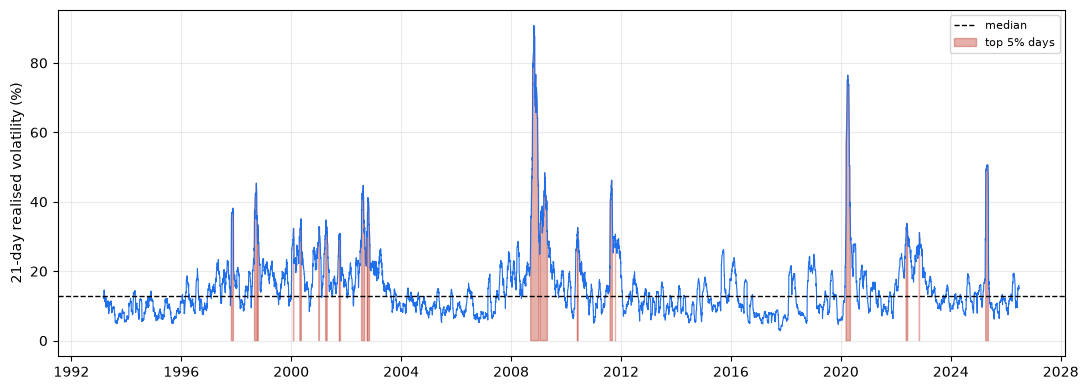

In [3]:
v = st.realised_vol(r, 21)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(v.index, v * 100, lw=0.8, color="#1f6feb")
ax.axhline(v.median() * 100, color="k", ls="--", lw=1, label="median")
ax.fill_between(v.index, 0, v * 100, where=(v > v.quantile(0.95)), color="#c0392b",
                alpha=0.4, label="top 5% days")
ax.set_ylabel("21-day realised volatility (%)"); ax.legend(fontsize=8)
plt.show()

The red patches are not scattered at random. They come in blocks — that is the clustering. The
question is how wide the blocks are.

## 2 · Five reasonable people, five answers

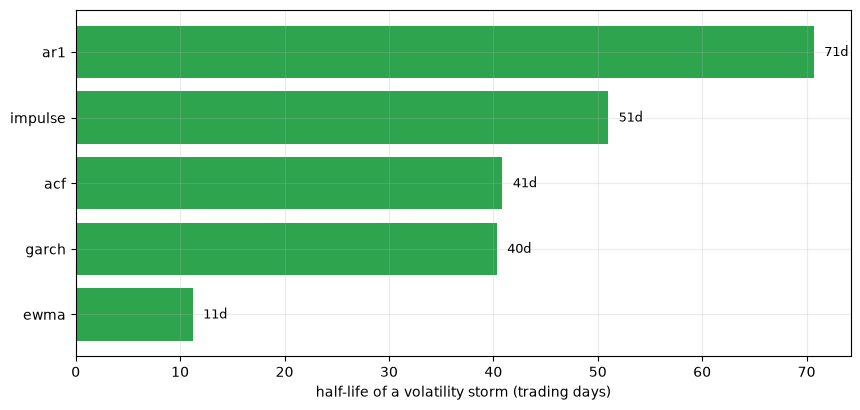

         halflife                                  note
method                                                 
ar1       70.6936      phi = 0.9902 on 21d realised vol
acf       40.8672             |returns|, acf(1) = 0.271
garch     40.3287                   alpha+beta = 0.9830
ewma      11.2023   lambda = 0.94, assumed not measured
impulse   51.0000  388 shocks above the 95th percentile


In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
tbl_sorted = tbl.sort_values("halflife")
ax.barh(range(len(tbl_sorted)), tbl_sorted["halflife"], color="#2ea44f")
ax.set_yticks(range(len(tbl_sorted))); ax.set_yticklabels(tbl_sorted.index)
ax.set_xlabel("half-life of a volatility storm (trading days)")
for i, (m, row) in enumerate(tbl_sorted.iterrows()):
    ax.text(row["halflife"] + 1, i, f"{row['halflife']:.0f}d", va="center", fontsize=9)
plt.show()
print(tbl.to_string())

> \U0001F52C **For the quants.** None of these is a mistake. The AR(1), the ACF crossing, the
> GARCH persistence and the impulse response are all standard and all correctly implemented. The
> EWMA row is different in kind — it is λ = 0.94 inverted, an assumption that ships inside a
> large share of the world's risk systems.

## 3 · The explanation: there are two storms

A squall that blows out in a few days, and a season of unsettled weather that lasts months.
Both are happening at once.

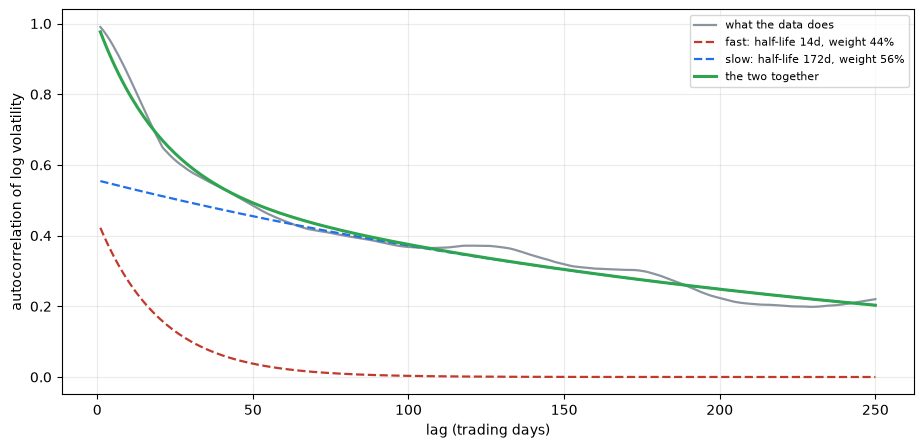

two components fit 100% better than one


In [5]:
tc = st.two_component_fit(r, 21)
lv = np.log(st.realised_vol(r, 21))
lags = np.arange(1, 251)
acf = np.array([lv.autocorr(int(k)) for k in lags])
w, t1, t2 = tc["weight_fast"], tc["tau_fast"], tc["tau_slow"]
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(lags, acf, lw=1.6, color="#8b949e", label="what the data does")
ax.plot(lags, w * np.exp(-lags / t1), lw=1.6, ls="--", color="#c0392b",
        label=f"fast: half-life {tc['halflife_fast']:.0f}d, weight {w:.0%}")
ax.plot(lags, (1 - w) * np.exp(-lags / t2), lw=1.6, ls="--", color="#1f6feb",
        label=f"slow: half-life {tc['halflife_slow']:.0f}d, weight {1 - w:.0%}")
ax.plot(lags, w * np.exp(-lags / t1) + (1 - w) * np.exp(-lags / t2), lw=2.2,
        color="#2ea44f", label="the two together")
ax.set_xlabel("lag (trading days)"); ax.set_ylabel("autocorrelation of log volatility")
ax.legend(fontsize=8)
plt.show()
print(f"two components fit {tc['improvement']:.0%} better than one")

An estimator that looks mostly at short lags reports the fast number. One that looks at long
lags reports the slow number. Both are answering honestly; they were asked different questions.

## 4 · What it means in practice

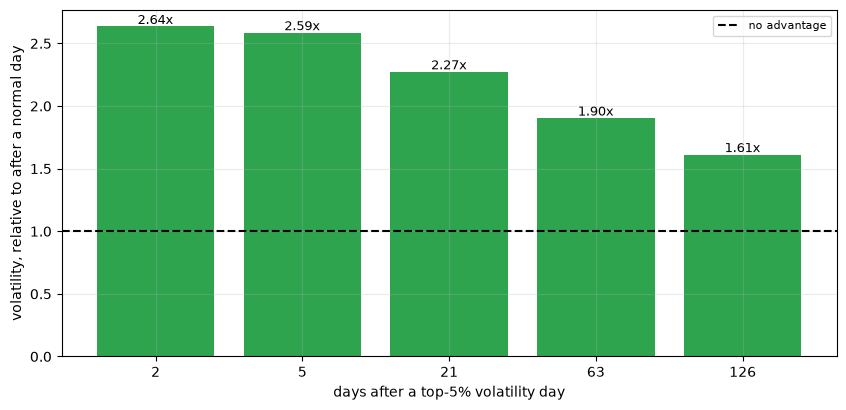

         n_hot  vol_after_shock  vol_after_calm  ratio
horizon                                               
2          388           1.7000          0.6450 2.6350
5          388           1.9470          0.7530 2.5850
21         388           1.8330          0.8060 2.2730
63         388           1.6110          0.8460 1.9040
126        388           1.4150          0.8770 1.6120


In [6]:
p = st.practical_decay(r, 21)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar([str(i) for i in p.index], p["ratio"], color="#2ea44f")
ax.axhline(1.0, color="k", ls="--", lw=1.5, label="no advantage")
ax.set_xlabel("days after a top-5% volatility day")
ax.set_ylabel("volatility, relative to after a normal day")
ax.legend(fontsize=8)
for i, (hz, row) in enumerate(p.iterrows()):
    ax.text(i, row["ratio"] + 0.02, f"{row['ratio']:.2f}x", ha="center", fontsize=9)
plt.show()
print(p.round(3).to_string())

## 5 · Different assets, different weather

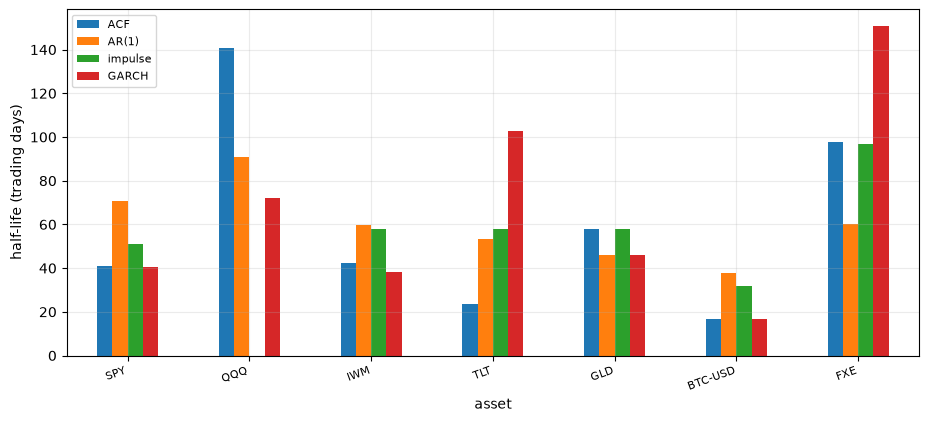

,ACF,AR(1),impulse,GARCH
asset,,,,
SPY,40.9000,70.7000,51.0000,40.3000
QQQ,140.9000,90.9000,NaN,72.3000
IWM,42.4000,59.6000,58.0000,38.3000
TLT,23.5000,53.4000,58.0000,102.9000
GLD,58.0000,46.1000,58.0000,45.8000
BTC-USD,16.9000,37.8000,32.0000,16.6000
FXE,97.9000,60.3000,97.0000,151.0000


In [7]:
rows = []
for tk, s in assets.items():
    t = st.halflife_table(s, 21)
    rows.append({"asset": tk, "ACF": t.loc["acf", "halflife"],
                 "AR(1)": t.loc["ar1", "halflife"],
                 "impulse": t.loc["impulse", "halflife"],
                 "GARCH": t.loc["garch", "halflife"]})
d = pd.DataFrame(rows).set_index("asset")
fig, ax = plt.subplots(figsize=(11, 4.5))
d.plot.bar(ax=ax)
ax.set_ylabel("half-life (trading days)"); ax.legend(fontsize=8, title="")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.show()
d.round(1)

## 6 · The verdict

**Signal: Confirmed.** For SPY over 7,764 sessions, the five standard ways of measuring the half-life of a volatility storm give **11 to 71 days** — a spread of 6.3×. They are not contradicting each other; they are measuring different things, because volatility is not one process. Fitting a two-component autocorrelation gives a **fast part with a 14.1-day half-life carrying 44% of the variation, and a slow part at 172 days** — a fit that beats the single-exponential version by **100%** of squared error. Every single-number estimator returns a weighted average of those two, weighted by whichever lags it happens to look at, which is why GARCH (40 days) systematically exceeds the raw autocorrelation reading (41 days) rather than differing from it at random. The model-free impulse response — after a 95th-percentile volatility day, how long until half the excess is gone — says **51 days**.

**Tradability: Useful.** The version that decides anything: after a top-5% volatility day, realised volatility over the next week ran **2.59×** the level following a normal day, over the next month **2.27×**, and over the next quarter 1.90×. That is a slow enough decay to reposition against — nobody needs a same-day reaction to exploit a signal that is still worth 2.27× a month later. Two caveats travel with it: the half-life is itself unstable (across the 7 assets here it ranges 32 to 97 days), and the AR(1) number is partly an artefact of the estimation window — sweeping that window from 1 to 63 days moves the answer from 0.4 to 409 days on identical data, attenuated at the short end by proxy noise and inflated at the long end by the rolling mean's own autocorrelation.

## 7 · Going further \U0001F6AA

- **Stop asking for one number.** A component GARCH (Engle & Lee 1999) or a HAR model (Corsi
  2009) uses several timescales on purpose, and both forecast better than any single-half-life
  model for exactly that reason.
- **Ask the options market.** The VIX term structure is the market's own view of how long the
  current storm will last, and it is available in real time.
- **Watch the half-life move.** Everything here is a full-sample average of something that is
  itself time-varying.